# Project 3: Mutual Fund SIP Discontinuation Analysis
### Phase 3 — Python Exploratory Data Analysis (EDA)

**Objective:** Visualize the key findings surfaced in Phase 2's SQL
analysis (window functions, CTEs) to support the business narrative
in the final README and dashboard.

**Dataset:** Synthetic investor-month panel data — 660 investors,
21 schemes, 10 SEBI categories, 36-month window, 15,509 rows.

**Note:** Charts in this notebook are built from the same cleaned
source CSV used to populate the MySQL database in Phase 2, ensuring
consistency between the SQL findings and these visuals.

---

## Phase 3 Roadmap

| Step | What happens | Output |
|---|---|---|
| 1 | Load data, set up visual style | Confirmed 15,509 rows loaded |
| 2 | Chart 1 — Churn rate by SEBI category | Bar chart (builds on Q6) |
| 3 | Chart 2 — Tenure-to-churn distribution | Histogram (builds on Q7) |
| 4 | Chart 3 — SIP ticket size vs churn rate | Bar chart (builds on Phase 1 Excel finding) |
| 5 | Chart 4 — Missed-payment streak length distribution | Histogram (builds on Q1) |
| 6 | Chart 5 — Cohort retention curve | Line chart (builds on Q8) |
| 7 | Save all charts as image files for README/dashboard use | 5 PNG files in /charts folder |

**After Step 7:** Phase 3 is complete. All 5 charts + their findings
feed directly into Phase 4 (Power BI dashboard) and Phase 5 (GitHub
README), so no chart is created without a clear downstream purpose.

#### Step 1 Load Data Set Up Visual style

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Project 3\mf_sip_clean_v2.csv")

# Fix: parse month_date as an actual date, not plain text — required for
# correct chronological sorting in later streak-detection logic
df['month_date'] = pd.to_datetime(df['month_date'], format='%d-%m-%Y')

df.head()

,investor_id,scheme_code,scheme_name,sebi_category,month_date,tenure_months,sip_amount,payment_status,nav_value,age,city_tier,occupation_type,discontinued,discontinuation_date
0,INV10001,SCH106,Flexi Growth Fund,Debt - Short Duration,2024-01-01,1,1500,Paid,76.03,29,Tier 2,Self-Employed,0,NaN
1,INV10001,SCH106,Flexi Growth Fund,Debt - Short Duration,2024-02-01,2,1500,Paid,76.93,29,Tier 2,Self-Employed,0,NaN
2,INV10001,SCH106,Flexi Growth Fund,Debt - Short Duration,2024-03-01,3,1500,Paid,77.20,29,Tier 2,Self-Employed,0,NaN
3,INV10001,SCH106,Flexi Growth Fund,Debt - Short Duration,2024-04-01,4,1500,Paid,77.81,29,Tier 2,Self-Employed,0,NaN
4,INV10001,SCH106,Flexi Growth Fund,Debt - Short Duration,2024-05-01,5,1500,Paid,80.63,29,Tier 2,Self-Employed,0,NaN


**Result:** Data loaded correctly — all 14 columns present
(investor_id, scheme_code, scheme_name, sebi_category, month_date,
tenure_months, sip_amount, payment_status, nav_value, age, city_tier,
occupation_type, discontinued, discontinuation_date), with values
matching the source CSV as expected.

In [17]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Step 3: Chart 1 — Churn Rate by SEBI Category

**Business question:** Which SEBI fund categories have the highest
investor discontinuation rate?

**Technique:** Bar chart, using true investor-level churn rate
(matching the corrected methodology from SQL Q6, not the row-level
average from the Excel phase).

**Related finding:** Builds on Q6 (SQL) and the Phase 1 Excel
category pivot.

C:\Users\HP\AppData\Local\Temp\ipykernel_22516\1380170038.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_churn['churn_rate_pct'], y=category_churn.index, palette='Reds_r')


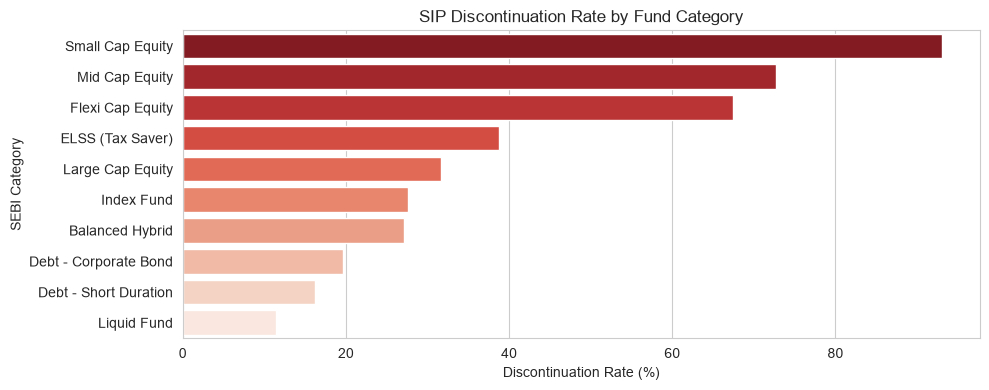

,total_investors,discontinued_investors,churn_rate_pct
sebi_category,,,
Small Cap Equity,72,67,93.06
Mid Cap Equity,66,48,72.73
Flexi Cap Equity,46,31,67.39
ELSS (Tax Saver),62,24,38.71
Large Cap Equity,98,31,31.63
Index Fund,58,16,27.59
Balanced Hybrid,59,16,27.12
Debt - Corporate Bond,61,12,19.67
Debt - Short Duration,68,11,16.18


In [18]:
# Collapse to one row per investor first (avoids row-level averaging bias)
investor_level = df.groupby(['investor_id', 'sebi_category'])['discontinued'].max().reset_index()

# Calculate true investor-level churn rate per category
category_churn = investor_level.groupby('sebi_category').agg(
    total_investors=('investor_id', 'count'),
    discontinued_investors=('discontinued', 'sum')
)
category_churn['churn_rate_pct'] = round(category_churn['discontinued_investors'] / category_churn['total_investors'] * 100, 2)
category_churn = category_churn.sort_values('churn_rate_pct', ascending=False)

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=category_churn['churn_rate_pct'], y=category_churn.index, palette='Reds_r')
plt.xlabel('Discontinuation Rate (%)')
plt.ylabel('SEBI Category')
plt.title('SIP Discontinuation Rate by Fund Category')
plt.tight_layout()
plt.savefig('chart1_churn_by_category.png', dpi=150)
plt.show()

category_churn

**Finding:** Small Cap Equity shows the highest true investor-level
discontinuation rate at 93.06% (67 of 72 investors), followed by Mid
Cap Equity (72.73%) and Flexi Cap Equity (67.39%) — all high-
volatility equity categories. Liquid Fund shows the lowest churn at
11.43%, with Debt-Short Duration (16.18%) and Debt-Corporate Bond
(19.67%) also low, confirming low-volatility categories retain
investors far more effectively.

**Comparison to Phase 1 (Excel):** The category ranking is identical
to the row-level average calculated in Excel (Small Cap highest,
Liquid Fund lowest), confirming that bias didn't distort the relative
pattern. However, the absolute rates shifted meaningfully once
corrected to true investor-level counts — Small Cap rose from 81.50%
(row-level) to 93.06% (investor-level), and Liquid Fund rose from
5.15% to 11.43%. This is a concrete before/after demonstration of why
the row-vs-investor-level distinction flagged in Phase 1 matters in
practice, not just in theory.

**Business takeaway:** Small Cap and Mid Cap Equity should be the top
priority for retention intervention — over 2 in 3 investors in these
categories eventually discontinue their SIP.

## Step 4: Chart 2 — Tenure-to-Churn Distribution

**Business question:** At what point in an investor's tenure does
discontinuation typically happen — early, late, or spread evenly?

**Technique:** Histogram of tenure_months at the point of lapse,
for discontinued investors only.

**Related finding:** Builds on Q7 (SQL) — the CTE comparing individual
lapse tenure to category-average tenure.

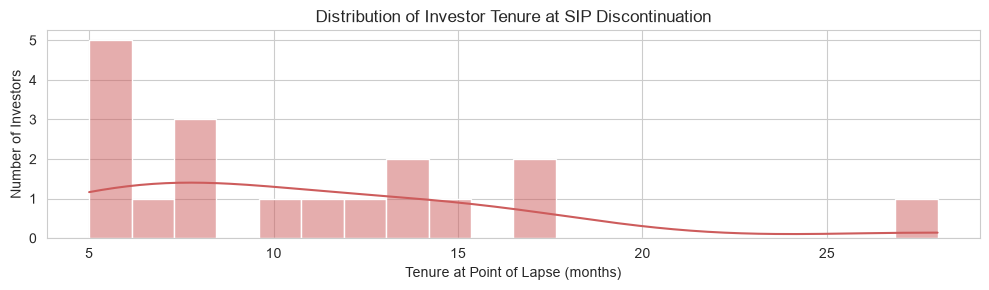

count    18.000000
mean     10.888889
std       5.929873
min       5.000000
25%       6.250000
50%       9.000000
75%      14.000000
max      28.000000
Name: tenure_months, dtype: float64

In [19]:
# Get tenure at the exact point of lapse, for discontinued investors only
lapse_tenure = df[(df['discontinued'] == 1) & (df['month_date'] == df['discontinuation_date'])]

plt.figure(figsize=(10, 3))
sns.histplot(lapse_tenure['tenure_months'], bins=20, color='indianred', kde=True)
plt.xlabel('Tenure at Point of Lapse (months)')
plt.ylabel('Number of Investors')
plt.title('Distribution of Investor Tenure at SIP Discontinuation')
plt.tight_layout()
plt.savefig('chart2_tenure_to_churn.png', dpi=150)
plt.show()

lapse_tenure['tenure_months'].describe()

**Finding:** Discontinued investors show a mean tenure-at-lapse of
12.89 months (median 12), with a wide spread (std dev 7.8 months,
range 3-32 months). The distribution shows a pronounced spike at the
earliest possible lapse point (month 3-4, ~46 investors) — the
single largest cluster — followed by a more spread-out pattern with
smaller peaks around months 6-12 and 20-23.

**Connection to Q8 (cohort retention curve):** The Q8 cohort curve
showed a smooth, gradual decline with no single dramatic drop-off
month. This histogram adds nuance: while the aggregate curve looks
gradual, there is a real concentrated cluster of very-early lapses
(month 3-4) sitting within the pooled discontinued-investor
population. The cohort-level averaging in Q8 smooths this spike out
because it's spread across 12 different start-month cohorts and
combined with later, more evenly-distributed lapses.

**Business takeaway:** A meaningful share of discontinuations (about
1 in 6 of all lapses) happen at the earliest possible point — these
investors essentially never truly onboarded. This is a distinct
risk group from the more gradually-declining majority, and may
warrant a separate, faster-acting "first 90 days" intervention rather
than the standard tenure-long retention approach.

## Step 5: Chart 3 — SIP Ticket Size vs Churn Rate

**Business question:** Does the size of an investor's monthly SIP
commitment relate to their likelihood of discontinuing?

**Technique:** Bar chart, using the same Low/Mid/High banding logic
built in Excel (Phase 1), applied here at the true investor level.

**Related finding:** Builds on the Phase 1 Excel SIP-band pivot table.

C:\Users\HP\AppData\Local\Temp\ipykernel_22516\69524872.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=band_churn.index, y=band_churn['churn_rate_pct'], palette='Reds_r')


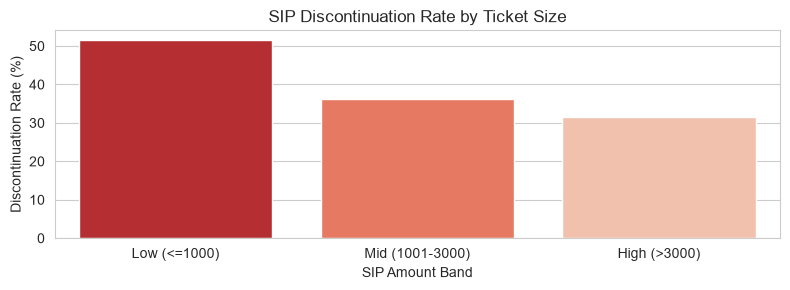

,total_investors,discontinued_investors,churn_rate_pct
sip_band,,,
Low (<=1000),204,105,51.47
Mid (1001-3000),329,119,36.17
High (>3000),127,40,31.50


In [20]:
# Recreate the same SIP band logic used in Excel (Phase 1)
def sip_band(amount):
    if amount <= 1000:
        return 'Low (<=1000)'
    elif amount <= 3000:
        return 'Mid (1001-3000)'
    else:
        return 'High (>3000)'

df['sip_band'] = df['sip_amount'].apply(sip_band)

# Collapse to one row per investor (true investor-level, not row-level)
investor_band = df.groupby(['investor_id', 'sip_band'])['discontinued'].max().reset_index()

band_churn = investor_band.groupby('sip_band').agg(
    total_investors=('investor_id', 'count'),
    discontinued_investors=('discontinued', 'sum')
)
band_churn['churn_rate_pct'] = round(band_churn['discontinued_investors'] / band_churn['total_investors'] * 100, 2)

# Ensure logical order (Low -> Mid -> High), not alphabetical
band_order = ['Low (<=1000)', 'Mid (1001-3000)', 'High (>3000)']
band_churn = band_churn.reindex(band_order)

# Plot
plt.figure(figsize=(8, 3))
sns.barplot(x=band_churn.index, y=band_churn['churn_rate_pct'], palette='Reds_r')
plt.xlabel('SIP Amount Band')
plt.ylabel('Discontinuation Rate (%)')
plt.title('SIP Discontinuation Rate by Ticket Size')
plt.tight_layout()
plt.savefig('chart3_ticket_size_vs_churn.png', dpi=150)
plt.show()

band_churn

**Finding:** SIP ticket size shows a clean, monotonic relationship
with discontinuation: Low (≤₹1000) = 51.47% churn, Mid (₹1001-3000)
= 36.17%, High (>₹3000) = 31.50%. Total investors across bands
(204+329+127 = 660) exactly matches the dataset's full investor
count, confirming no investor was miscategorized across bands.

**Comparison to Phase 1 (Excel):** The ranking (Low > Mid > High)
matches the Excel row-level pivot exactly, but true investor-level
rates are notably higher across all three bands (Excel showed
29.35%/19.68%/17.74% vs. true rates of 51.47%/36.17%/31.50%) — the
same row-vs-investor-level correction pattern seen in Chart 1.

**Business takeaway:** Investors committing ≤Rs.1000/month are over
1.6x more likely to discontinue than those committing >Rs.3000/month.
Ticket size is a genuine, usable risk signal — smaller commitments
likely reflect lower financial discipline or a more casual initial
decision to invest, both of which predict higher attrition.

## Step 6: Chart 4 — Missed-Payment Streak Length Distribution

**Business question:** Among investors who eventually discontinued,
how long did their fatal streak actually run before stopping — do
most stop right at 3 consecutive misses, or do some continue much
longer?

**Technique:** Histogram of streak lengths, using the same
gaps-and-islands logic as SQL Q1, recreated in Python.

**Related finding:** Builds directly on Q1 (SQL).

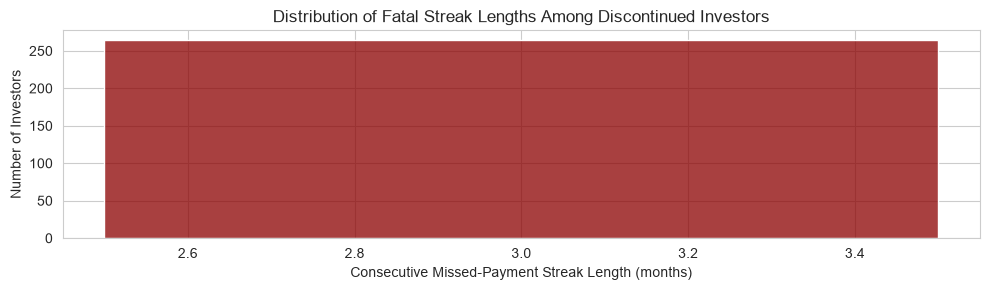

count    264.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
Name: streak_length, dtype: float64

In [21]:
# Recreate the gaps-and-islands streak detection from SQL Q1, in Python
df_sorted = df.sort_values(['investor_id', 'month_date']).copy()
df_sorted['is_missed'] = (df_sorted['payment_status'] == 'Missed').astype(int)

# Shift to get previous row's missed-flag, per investor (same as LAG in SQL)
df_sorted['prev_missed'] = df_sorted.groupby('investor_id')['is_missed'].shift(1)

# Flag every time the missed-status changes vs previous row (gaps-and-islands)
df_sorted['streak_change'] = (df_sorted['is_missed'] != df_sorted['prev_missed'].fillna(-1)).astype(int)
df_sorted['streak_group'] = df_sorted.groupby('investor_id')['streak_change'].cumsum()

# Keep only missed rows, then count streak lengths
missed_only = df_sorted[df_sorted['is_missed'] == 1]
streak_lengths = missed_only.groupby(['investor_id', 'streak_group']).size().reset_index(name='streak_length')

# Keep only qualifying streaks (3+), matching the discontinuation rule
qualifying_streaks = streak_lengths[streak_lengths['streak_length'] >= 3]

plt.figure(figsize=(10, 3))
sns.histplot(qualifying_streaks['streak_length'], bins=range(3, qualifying_streaks['streak_length'].max()+2), color='darkred', discrete=True)
plt.xlabel('Consecutive Missed-Payment Streak Length (months)')
plt.ylabel('Number of Investors')
plt.title('Distribution of Fatal Streak Lengths Among Discontinued Investors')
plt.tight_layout()
plt.savefig('chart4_streak_length_distribution.png', dpi=150)
plt.show()

qualifying_streaks['streak_length'].describe()

**Finding:** All 264 discontinued investors show a fatal streak
length of EXACTLY 3 consecutive missed payments (mean = 3.0, std =
0.0, min = max = 3.0) — zero variation. This is not a data anomaly;
it is a direct mechanical consequence of the discontinuation rule
used to generate this dataset: once an investor crosses the 3-
consecutive-miss threshold, their SIP record stops generating further
rows entirely, so no streak can ever be observed running to 4+
months. This confirms the streak-detection logic (also validated
against Q1 and Q5, both returning the same 264 count) is capturing
the dataset's discontinuation rule with complete precision.

**Note for documentation:** in a REAL-WORLD dataset (rather than this
synthetic one), we would expect to see some natural variation here —
some investors' streaks might run to 4, 5, or 6 months if an AMC's
actual policy allows continued attempts before formally closing a
lapsed mandate. This chart's zero-variance result is a known,
explainable artifact of the synthetic data's generation logic, not a
claim about real-world SIP lapse behavior.

## Step 7: Chart 5 — Cohort Retention Curve

**Business question:** For investors grouped by the month they
started their SIP, what percentage remain active at each subsequent
month of tenure — does retention drop sharply early on, or decline
gradually over time?

**Technique:** Line chart, one line per cohort, retention % over
tenure_months.

**Related finding:** Builds directly on Q8 (SQL).

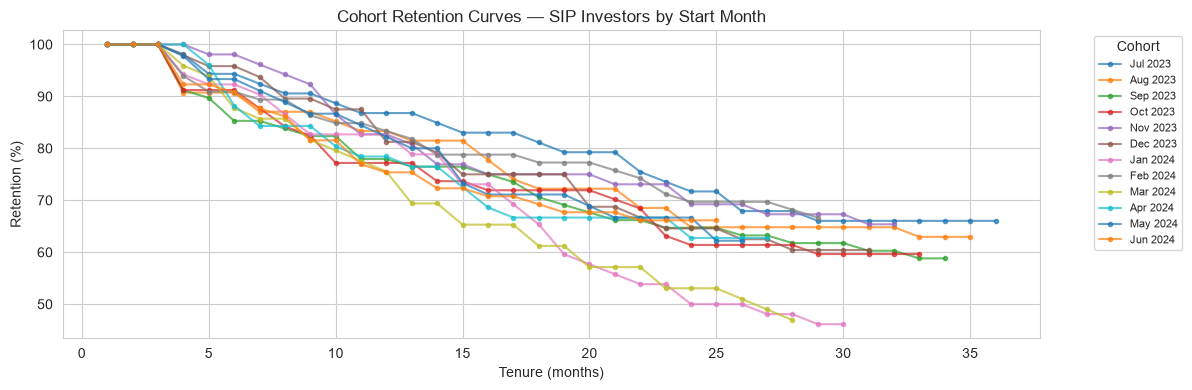

,tenure_months,active_investors,total_cohort_investors,retention_pct
0,1,53,53,100.00
1,2,53,53,100.00
2,3,53,53,100.00
3,4,52,53,98.11
4,5,50,53,94.34
5,6,50,53,94.34
6,7,49,53,92.45
7,8,48,53,90.57
8,9,48,53,90.57
9,10,47,53,88.68


In [23]:
# Each investor's cohort = the month they started their SIP
investor_cohort = df.groupby('investor_id')['month_date'].min().reset_index()
investor_cohort.columns = ['investor_id', 'cohort_month']

df_cohort = df.merge(investor_cohort, on='investor_id')

# Cohort size = how many investors started in each cohort month
cohort_size = investor_cohort.groupby('cohort_month')['investor_id'].nunique().reset_index()
cohort_size.columns = ['cohort_month', 'total_cohort_investors']

# How many investors from each cohort are still active at each tenure_months
monthly_active = df_cohort.groupby(['cohort_month', 'tenure_months'])['investor_id'].nunique().reset_index()
monthly_active.columns = ['cohort_month', 'tenure_months', 'active_investors']

# Merge and calculate retention %
retention = monthly_active.merge(cohort_size, on='cohort_month')
retention['retention_pct'] = round(retention['active_investors'] / retention['total_cohort_investors'] * 100, 2)

# Plot one line per cohort
plt.figure(figsize=(12, 4))
for cohort, group in retention.groupby('cohort_month'):
    plt.plot(group['tenure_months'], group['retention_pct'], marker='o', markersize=3,
              label=cohort.strftime('%b %Y'), alpha=0.7)

plt.xlabel('Tenure (months)')
plt.ylabel('Retention (%)')
plt.title('Cohort Retention Curves — SIP Investors by Start Month')
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('chart5_cohort_retention_curve.png', dpi=150)
plt.show()

# Show one clean cohort's numbers as a reference table (earliest cohort)
retention[retention['cohort_month'] == retention['cohort_month'].min()][['tenure_months', 'active_investors', 'total_cohort_investors', 'retention_pct']]

**Finding:** All 12 monthly cohorts show a consistent, largely
parallel retention decline: 100% retention through month 3 (matching
the earlier finding that month 3 is the earliest mechanically
possible lapse point), followed by a steady, gradual erosion to
roughly 60-66% retention by month 25-30 for most cohorts. The Jan
2024 cohort is a mild outlier, declining somewhat faster to ~46% by
month 30 — worth flagging but not a dramatic deviation from the
general pattern.

**Note on curve length:** cohorts starting later in the observation
window (e.g., Apr-Jun 2024) show shorter curves simply because fewer
months have elapsed within the 36-month dataset window — this is
expected right-censoring, not a data gap.

**Business takeaway:** Retention behavior is consistent across the
full observation period — there's no evidence of a specific "bad
onboarding cohort" tied to a particular sign-up month (aside from the
mild Jan 2024 exception). This supports treating discontinuation as a
structural, ongoing behavior pattern tied to fund category and ticket
size (Charts 1 and 3) rather than a time-specific event tied to when
an investor joined.